<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/005_transfer_learning_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN treinada do zero vs MobileNetV2 pré-treinada no ImageNet

**Área:** Computer Vision  
**Nível:** 🟡 Intermediate  
**Tipo de problema:** Classificação multiclasse de imagens

### Pergunta de estudo

> Reutilizar representações aprendidas em um grande dataset melhora a classificação de imagens em relação a uma CNN pequena treinada do zero?

### Experimentos

1. pequena CNN treinada do zero;
2. MobileNetV2 congelada como extratora de características;
3. fine-tuning parcial da MobileNetV2.

### Observação de execução

Este notebook se beneficia bastante de **GPU no Google Colab**.

O parâmetro `FAST_MODE` permite reduzir o conjunto de treino para uma execução exploratória.  
Para o resultado a ser publicado, recomenda-se executar com `FAST_MODE = False`.


## 1. Configuração do ambiente


In [1]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    Resizing,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use False para o resultado final do repositório.
FAST_MODE = False

print("TensorFlow:", tf.__version__)
print("GPU disponível:", bool(tf.config.list_physical_devices("GPU")))


TensorFlow: 2.20.0
GPU disponível: False


## 2. Carregamento do CIFAR-10

O CIFAR-10 contém imagens coloridas `32 × 32` distribuídas em dez classes.


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Treino original:", x_train_full.shape)
print("Teste:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2749s 16us/step
Treino original: (50000, 32, 32, 3)
Teste: (10000, 32, 32, 3)


In [3]:
# Cria treino e validação estratificados.
train_idx, val_idx = train_test_split(
    np.arange(len(x_train_full)),
    test_size=5_000,
    random_state=SEED,
    stratify=y_train_full,
)

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]

x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]

# Modo rápido: usa uma amostra estratificada do treino.
if FAST_MODE:
    selected_idx, _ = train_test_split(
        np.arange(len(x_train)),
        train_size=12_000,
        random_state=SEED,
        stratify=y_train,
    )
    x_train = x_train[selected_idx]
    y_train = y_train[selected_idx]

print("Treino:", x_train.shape)
print("Validação:", x_val.shape)
print("Teste:", x_test.shape)


Treino: (45000, 32, 32, 3)
Validação: (5000, 32, 32, 3)
Teste: (10000, 32, 32, 3)


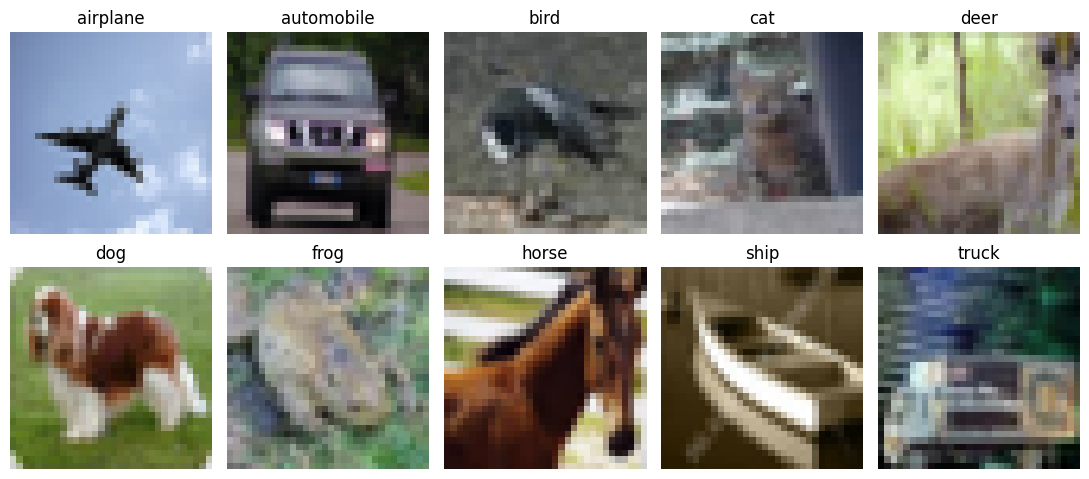

In [4]:
# Visualiza exemplos.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for class_id, ax in enumerate(axes.ravel()):
    idx = np.where(y_train == class_id)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[class_id])
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Baseline — pequena CNN treinada do zero

O baseline aprende todos os filtros diretamente a partir do CIFAR-10.


In [5]:
baseline_model = Sequential([
    Input(shape=(32, 32, 3)),
    tf.keras.layers.Rescaling(1.0 / 255),

    Conv2D(32, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dropout(0.30),
    Dense(10, activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

baseline_history = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15 if not FAST_MODE else 6,
    batch_size=128,
    callbacks=[baseline_early_stopping],
    verbose=1,
)


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 95s 265ms/step - accuracy: 0.2883 - loss: 1.8843 - val_accuracy: 0.3654 - val_loss: 1.6921
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 146s 276ms/step - accuracy: 0.3918 - loss: 1.6375 - val_accuracy: 0.4434 - val_loss: 1.5162
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.4439 - loss: 1.5201 - val_accuracy: 0.4858 - val_loss: 1.4013
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 276ms/step - accuracy: 0.4790 - loss: 1.4381 - val_accuracy: 0.5236 - val_loss: 1.3084
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.5079 - loss: 1.3634 - val_accuracy: 0.5408 - val_loss: 1.2622
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - accuracy: 0.5261 - loss: 1.3095 - val_accuracy: 0.5740 - val_loss: 1.2081
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - accuracy: 0.5457 - loss: 1.2639 - val_accuracy: 0.5916 - val_loss: 1.1642
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - accuracy: 0.5638 - lo

## 4. Transfer Learning com MobileNetV2

A MobileNetV2 foi treinada previamente no ImageNet.

O fluxo adotado é:

1. aumentar os dados;
2. redimensionar as imagens para `96 × 96`;
3. aplicar o pré-processamento esperado pela MobileNetV2;
4. congelar o backbone;
5. treinar um novo classificador para CIFAR-10.


In [ ]:
# Data augmentation aplicado somente durante treinamento.
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
], name="data_augmentation")

# Backbone pré-treinado.
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(96, 96)(x)
x = preprocess_input(x)

# training=False mantém BatchNorm em modo de inferência.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.30)(x)
outputs = Dense(10, activation="softmax")(x)

transfer_model = Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()


In [ ]:
transfer_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

transfer_history = transfer_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10 if not FAST_MODE else 5,
    batch_size=128,
    callbacks=[transfer_early_stopping],
    verbose=1,
)


## 5. Avaliação antes do fine-tuning

Antes de descongelar parte do backbone, registramos o resultado obtido apenas com extração de características.


In [ ]:
transfer_frozen_probabilities = transfer_model.predict(x_test, batch_size=256, verbose=0)
transfer_frozen_predictions = transfer_frozen_probabilities.argmax(axis=1)

transfer_frozen_accuracy = accuracy_score(y_test, transfer_frozen_predictions)

print(f"Accuracy — backbone congelado: {transfer_frozen_accuracy:.4f}")


## 6. Fine-tuning parcial

Após o novo classificador aprender a tarefa, as últimas camadas do backbone são liberadas.

O learning rate é reduzido para evitar atualizações agressivas nos pesos pré-treinados.


In [ ]:
# Libera o backbone e congela todas as camadas exceto as 20 últimas.
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"Camadas treináveis no backbone: {trainable_count}")


In [ ]:
fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

fine_tune_history = transfer_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=6 if not FAST_MODE else 3,
    batch_size=128,
    callbacks=[fine_tune_early_stopping],
    verbose=1,
)


## 7. Avaliação final

Os três estados são comparados:

- CNN treinada do zero;
- MobileNetV2 congelada;
- MobileNetV2 após fine-tuning.


In [ ]:
baseline_probabilities = baseline_model.predict(x_test, batch_size=256, verbose=0)
baseline_predictions = baseline_probabilities.argmax(axis=1)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

fine_tuned_probabilities = transfer_model.predict(x_test, batch_size=256, verbose=0)
fine_tuned_predictions = fine_tuned_probabilities.argmax(axis=1)
fine_tuned_accuracy = accuracy_score(y_test, fine_tuned_predictions)

results = pd.DataFrame({
    "Modelo": [
        "CNN do zero",
        "MobileNetV2 congelada",
        "MobileNetV2 fine-tuned",
    ],
    "Accuracy": [
        baseline_accuracy,
        transfer_frozen_accuracy,
        fine_tuned_accuracy,
    ],
}).set_index("Modelo")

display(results.round(4))


In [ ]:
print("MOBILENETV2 — FINE-TUNED")
print(
    classification_report(
        y_test,
        fine_tuned_predictions,
        target_names=class_names,
        digits=4,
    )
)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    fine_tuned_predictions,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title("Matriz de confusão — MobileNetV2 fine-tuned")
plt.tight_layout()
plt.show()


## 8. Análise de erros


In [ ]:
wrong_indices = np.where(fine_tuned_predictions != y_test)[0]

rng = np.random.default_rng(SEED)
sample_size = min(15, len(wrong_indices))
sample_indices = rng.choice(wrong_indices, size=sample_size, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for idx, ax in zip(sample_indices, axes.ravel()):
    ax.imshow(x_test[idx])
    ax.set_title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[fine_tuned_predictions[idx]]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 9. Conclusão


In [ ]:
from IPython.display import Markdown, display

winner = results["Accuracy"].idxmax()
winner_accuracy = results.loc[winner, "Accuracy"]
gain_vs_baseline = (fine_tuned_accuracy - baseline_accuracy) * 100
fine_tune_gain = (fine_tuned_accuracy - transfer_frozen_accuracy) * 100

conclusion = f'''
### Síntese dos resultados

O melhor resultado desta execução foi obtido por **{winner}**, com accuracy de **{winner_accuracy:.4f}**.

Comparando especificamente:

- **CNN do zero:** {baseline_accuracy:.4f}
- **MobileNetV2 congelada:** {transfer_frozen_accuracy:.4f}
- **MobileNetV2 fine-tuned:** {fine_tuned_accuracy:.4f}

O fine-tuning alterou a accuracy em **{fine_tune_gain:+.2f} pontos percentuais** em relação ao backbone congelado.
Em relação à CNN treinada do zero, a MobileNetV2 fine-tuned apresentou diferença de **{gain_vs_baseline:+.2f} pontos percentuais**.

### Interpretação

Transfer learning permite reutilizar representações visuais aprendidas previamente.
Entretanto, o ganho não é garantido: ele depende da proximidade entre os domínios, resolução das imagens, estratégia de fine-tuning e quantidade de dados disponíveis.

### Limitações

- CIFAR-10 possui imagens muito pequenas em relação ao ImageNet;
- o redimensionamento não cria novos detalhes visuais;
- foi utilizada apenas uma arquitetura pré-treinada;
- o tuning de hiperparâmetros foi limitado;
- tempo de treino e custo computacional não foram formalmente medidos.

### Próximos experimentos

1. EfficientNet/ConvNeXt;
2. comparar diferentes resoluções;
3. data augmentation mais forte;
4. medir tempo, memória e quantidade de parâmetros;
5. fine-tuning com diferentes quantidades de camadas liberadas.
'''

display(Markdown(conclusion))


## Referências

- CIFAR-10 — `keras.datasets.cifar10`
- MobileNetV2 — Keras Applications
- Transfer Learning & Fine-Tuning — Keras Guide
